# Task : classify emails as spam or ham with high precision (and high recall as well)

### Redefining Print Function

In [1]:
# The below will end the main print function with \n\n instead of just \n 
# This is only for convenience in reading output


import builtins

def print(*args, **kwargs):
    if 'end' not in kwargs:
        kwargs['end'] = '\n\n'
    builtins.print(*args, **kwargs)


## Importing modules 

In [2]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline 

from sklearn.base import BaseEstimator,TransformerMixin

from sklearn.metrics import precision_recall_curve,roc_auc_score,classification_report,confusion_matrix

from sklearn.utils import shuffle

from sklearn.model_selection import StratifiedShuffleSplit,cross_val_predict,cross_val_score

from sklearn.svm import SVC



import zipfile

from email import policy
from email.parser import Parser

import re 
# we can also use nltk instead of re : from nltk.tokenize import word_tokenize as tokenize

# from nltk.stem import PorterStemmer 
# we are not using nltk.stem because we have a more faster way to stem : Using PyStemmer Module

import Stemmer

from pathlib import Path

from bs4 import BeautifulSoup

from typing import Literal

from time import time


## Downloading and extracting Data

 This code only needs to be run once 

```python

zip_path = './datasets/archive.zip'

extract_path = './datasets/emails'

with zipfile.ZipFile(zip_path,'r') as zipref :
    zipfile.ZipFile.extractall(zipref,extract_path)

```

## Loading Data & Plan to approach the problem

open some of the examples from any folder and get familiar with the data format

There are three folders here :

- spam : which  obviously contains spam emails
- easy ham : contains those ham (i.e. not spam) emails which can be easily said that these are not spam
- hard ham : contains those ham emails which hard to be distinguised as ham

#### Looking at examples, seems like we will need lot of regex .....

However it will become way too complicated to parse an email  using regex....  
instead we will be using python's email module 

**PLAN :** first we will create an array with filenames with their labels in sequence - easy ham, hard ham and spam  
We will denote 1 as spam and 0 as ham

then, we will use stratified shuffling to split into training set and test set

so we will have initially X as n by 1 matrix, containing file name of each instance in a row, and y as n by 1 matrix
(here n is no, of instances)

then we will create a data transformation pipeline which will convert this filename vector into a feature matrix (ofcourse, it will have lot of hyperparameters to control the flow)

[ this pipeline will also be used to process the test set data (test filename vector) to convert it into feature matrix of test set]



Now we are going to create array of file names with their labels whether they are spam or not

In [3]:
easy_ham = np.array([ file.name for file in Path('./datasets/emails/easy_ham/easy_ham').iterdir() if (file.is_file()) ])

print(len(easy_ham))

hard_ham = np.array([ file.name for file in Path('./datasets/emails/hard_ham/hard_ham').iterdir() if (file.is_file()) ])

print(len(hard_ham))

spam = np.array([ file.name for file in Path('./datasets/emails/spam_2/spam_2').iterdir() if (file.is_file() & (file.name != 'cmds')) ])

print(len(spam))



2551

250

1396



## Preparing the Data and splitting it into test set

Now we ready to merge easy_ham, hard-ham and spam and make a label set


but before splitting it further into training set and test set, we want two things

 - we want splitting to be stratified in the sense that both training set and test set has same proportion of easy_ham, hard_ham and spam emails (tho we will be classifying as spam or ham only). this is done so that testing remains fair.

 - After stratified shuffling and splitting, we want to access indices of easy_ham and hard_ham so that we can check model scores on both of these instances(its score would intuitively be better on easy_ham instances than hard_ham instances)

In order to achieve these, we will first make three classes (0,0.5,1) where 0 is for easy_ham, 0.5 is for hard_ham and 1 for spam. Then we will do stratified splitting based on these classes, then store indices for easy_ham and hard_ham and then change all 0.5 labels to 0

In [4]:
filenames = np.concatenate((easy_ham,hard_ham,spam))
labels = np.repeat([0,0.5,1],[len(easy_ham),len(hard_ham),len(spam)])


split = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

(train_set_indices,test_set_indices), = split.split(filenames,labels)

X_train_fn = filenames[train_set_indices]           # fn denoting filenames here
Y_train_fn = labels[train_set_indices]

X_test_fn = filenames[test_set_indices]
Y_test_fn = labels[test_set_indices]

easy_ham_train_indices = np.where(Y_train_fn==0)
hard_ham_train_indices = np.where(Y_train_fn==0.5)

easy_ham_test_indices = np.where(Y_test_fn==0)
hard_ham_test_indices = np.where(Y_test_fn==0.5)


# Now changing the 0.5 label to 0

Y_train_fn[hard_ham_train_indices] = 0
Y_test_fn[hard_ham_test_indices] = 0



## Making a Data transformation Pipeline

our aim is to make a data transformation pipeline to convert filename vector to a feature matrix, with lot of hyperparameters to have control in this coversion

First, we need a transformer which can use filename to parse the email into headers and body, withh hyperparameters controlling stuffs (like to convert email body to lowercase, to output header, etc...)


However, before that, we need list of all possible words contained in all emails (we'll call it dictionary here) .... (This is because we will be converting to our feature matrix as number of counts of a particular words, with [total number of features being total number of possible words, punctuations and digits] plus url count, title etc.)
This will be done as follows : 


### Creating a class for FileOperations & EmailOperations



In [5]:
class FileOperations :

    @staticmethod
    def read(filepath,possible_encodings = ['utf-8','iso-8859-9','windows-1254'],return_as_list = False) :
        """
        Make sure to provide 'utf-8' encoding at first element in the list.\n
        """

    
        for encoding_ in possible_encodings :
            try : 
                return Path(filepath).read_text(encoding=encoding_).split(" ") if return_as_list else Path(filepath).read_text(encoding=encoding_)
            except UnicodeDecodeError :
                continue
        else :
            raise UnicodeDecodeError('Please provide valid encodings in list possible_encoding')
                    
    
    @staticmethod
    def write(filepath,text,encoding='utf-8') :
        try : 
            return Path(filepath).write_text(text,encoding=encoding)
        except UnicodeEncodeError :
            raise UnicodeEncodeError('Please Provide valid encoding')
    
        

In [6]:
class EmailOperations :

    def __init__(self,raw_email_message) :
        self.message = Parser(policy=policy.default).parsestr(raw_email_message)

        

    def subject(self,return_as_list_of_words=False) :
        return re.findall(r'[a-zA-Z]+',str(self.message['subject'])) if return_as_list_of_words else str(self.message['subject'])
    
    def body(self,return_as_list_of_words = False,strip_links = False) :
        text_parts = []
        for part in self.message.walk() :
            if (part.get_content_type() not in ['text/plain','text/html']) or ('attachment' in str(part.get_content_disposition()))  : 
                continue

            try : 
                body_text_of_part_raw = part.get_payload(decode=True).decode(self.message.get_content_charset())
            except :
                body_text_of_part_raw = part.get_payload()
            
            body_text_of_part = BeautifulSoup(body_text_of_part_raw,'html.parser').get_text(separator=" ",strip=True) 
            # ^^^ parses html to plain text and gives output unchanged if input is plain text
            if strip_links : 
                body_text_of_part = re.sub(r'https?://\S+','',body_text_of_part) 
                # replacing all links with nothing (as we will be counting number of links seperately)

            text_parts.append(body_text_of_part)
        
        return re.findall(r'[a-zA-Z]+',"\n\n".join(text_parts)) if return_as_list_of_words else "\n\n".join(text_parts)
            
        
        



### Creating a class to make/load Dictionary 

In [7]:
class Dictionary(FileOperations,EmailOperations) :

    @staticmethod
    def make_dictionary(path_of_directory,mode:Literal['subject','body'],save=True,path_to_save='./'):
        """ 
        path_of_directory is folder directory containing all the files, from which dictionary is to be made\n
        path_to_save should also include the filename
        """
        
        dictionary = np.array([])
        for file in Path(path_of_directory).iterdir() :
            raw_message = FileOperations.read(filepath=file)

            if mode == 'subject' : 
                dictionary = np.unique(np.concatenate((dictionary,EmailOperations(raw_message).subject(return_as_list_of_words=True))))
            
            elif mode == 'body'  : 
                dictionary = np.unique(np.concatenate((dictionary,EmailOperations(raw_message).body(return_as_list_of_words=True,strip_links=True))))
            
            else :
                raise ValueError("Please choose mode from ['subject','body']")
            
        if save :
            FileOperations.write(path_to_save," ".join(dictionary))

        return dictionary
    
    @staticmethod
    def load_dictionary(saved_path) : 
        """  
        saved_path should include the filename
        """

        return FileOperations.read(saved_path)


            





            

### Make Dictionary parts (subject and body)
**NOTE :** this only need to be run once

In [ ]:
subject_dictionary = Dictionary.make_dictionary(path_of_directory='./datasets/emails/all/',mode='subject',save=True,path_to_save='./datasets/emails/subject_dictionary.txt')


In [ ]:
print(len(subject_dictionary))

In [ ]:
body_dictionary = Dictionary.make_dictionary(path_of_directory='./datasets/emails/all/',mode='body',save=True,path_to_save='./datasets/emails/body_dictionary.txt')


In [ ]:
print(len(body_dictionary))

### Load Dictionary parts and make final dictionary

In [8]:
subject_dictionary = Dictionary.load_dictionary('./datasets/emails/subject_dictionary.txt').split(" ")

body_dictionary = Dictionary.load_dictionary('./datasets/emails/body_dictionary.txt').split(" ")

print(len(subject_dictionary))
print(len(body_dictionary))


6297

63736



In [9]:
stemmer = Stemmer.Stemmer('english').stemWords
final_dictionary = np.unique(stemmer(np.char.lower(np.concatenate((subject_dictionary,body_dictionary)))))

print(len(final_dictionary))

40806



### Preparing Data Pipeline

In [10]:
class ReadEmail(FileOperations,BaseEstimator,TransformerMixin) :
    def __init__(self,directory_path : str):
        self.directory_path = directory_path

    def fit(self,X,y=None):
        return self
    
    def transform(self, X):
        read_email_content = np.vectorize(lambda filename : FileOperations.read(self.directory_path + filename))
        return read_email_content(X)
        


class ParseEmail(EmailOperations,BaseEstimator,TransformerMixin) :
    def __init__(self,return_numbers_count=False,return_symbols_count=False,return_sep_url_count=True) :
        """  
        sep_url_count, if true will give http and https links seperately, else it will count them together
        """
        self.return_numbers_count = return_numbers_count
        self.return_symbols_count = return_symbols_count
        self.return_sep_url_count = return_sep_url_count



    def fit(self,X,y=None) :
        return self
    
    def __parse_element(self,element) :
        subject = str(EmailOperations(element).subject())
        body_without_links = str(EmailOperations(element).body(strip_links=True))
        body_with_links = str(EmailOperations(element).body(strip_links=False))

        if self.return_sep_url_count :
            links_count = len(re.findall(r'https://\S+',body_with_links)),len(re.findall(r'http://\S+',body_with_links))
        else :
            links_count = (len(re.findall(r'https?://\S+',body_with_links)),)
        
        if self.return_numbers_count :
            number_counts = len(re.findall(r'\d',body_without_links))
        else :
            number_counts = 0
        
        if self.return_symbols_count :
            symbol_counts = len(re.findall(r'[^\w\s]',body_without_links))
        else :
            symbol_counts = 0
        
        return np.array([subject,body_without_links,*links_count,number_counts,symbol_counts],dtype=object)

        

        

    def transform(self,X) :
        return np.vectorize(self.__parse_element,signature='()->(p)',otypes=[object])(X)
    

        
class Count(BaseEstimator,TransformerMixin) :
    def __init__(self):
        pass

    def fit(self,X,y=None) :
        return self
    
    def __count_elements(self,element) :
        stemmer = Stemmer.Stemmer('english').stemWords
        subject_as_words = stemmer(re.findall(r'[a-zA-Z]+',element[0]))
        body_as_words = stemmer(re.findall(r'[a-zA-Z]+',element[1]))
        subject_plus_body = np.concatenate((subject_as_words,body_as_words))
        frequency_count = np.sum(final_dictionary[:,np.newaxis] == subject_plus_body[np.newaxis,:],axis=1)

        return np.concatenate((frequency_count,element[2:]))
    
    def transform(self,X) :
        return np.vectorize(self.__count_elements,signature='(m)->(p)',otypes=[object])(X)
    


In [ ]:
data_pipeline = Pipeline([
    ('1',ReadEmail('./datasets/emails/all/')),
    ('2',ParseEmail(return_numbers_count=True,return_sep_url_count=True,return_symbols_count=True)),
    ('3',Count()),
])

X_train = data_pipeline.fit_transform(X_train_fn,Y_train_fn)


### Saving the huge feature matrix we got from data transformation

In [ ]:
np.save('./datasets/emails/saved/X_train.npy',X_train)

### Loading the feature matrix

In [12]:
X_train = np.load('./datasets/emails/saved/X_train.npy',allow_pickle=True)
Y_train = Y_train_fn # ofcourse, the labels dont change


In [13]:
print(X_train.shape)

(3357, 40810)



let's look at a single instance to ensure the it's fine

In [18]:
np.set_printoptions(threshold=100,edgeitems=10)
print(X_train[238]) 

[15 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 2 20 124]



## Choosing and training the model


### Estimating training time (very rough estimation)

Estimated Training time :  11422.40511059761 seconds

Estimated Training time :  5987.494885146618 seconds

Estimated Training time :  3482.704615187645 seconds

Estimated Training time :  2457.6015463113786 seconds

Estimated Training time :  2482.379997253418 seconds

Estimated Training time :  2466.4146933853626 seconds

Estimated Training time :  1891.3240032434464 seconds

Estimated Training time :  2170.9840181797745 seconds

Estimated Training time :  1633.1612742841244 seconds

Estimated Training time :  1275.0175810799003 seconds

Estimated Training time :  1331.7172123861312 seconds

Estimated Training time :  1179.5473286658525 seconds

Estimated Training time :  1172.4924002945422 seconds

Estimated Training time :  1040.5647675320506 seconds

Estimated Training time :  794.4448442257941 seconds

Final estimated time based on O(m) fitting :  850.4744613513352



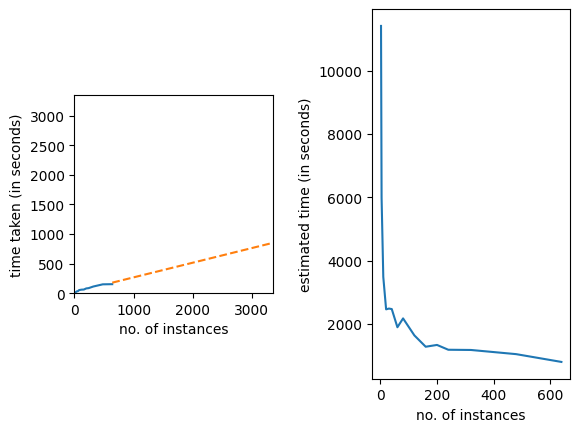

In [19]:
# to estimate training time 

model = SVC(kernel="linear",C=0.8)

#m_list = [2,4,10,20,30,40,60,80,120,160,200,240,320,480,640]
m_list = [2,4,10,20,30,40,60,80,120,160,200,240,320,480,640]

t_list = []

t_est_list = []

figs,axes = plt.subplots(nrows=1,ncols=2)

ax1 = axes[0]
ax2 = axes[1]

for m in m_list :

    t1 = time()

    model.fit(X_train[:m,:],Y_train[:m])
    Y_train_predict = model.predict(X_train)

    t2 = time()


    t_list.append(t2-t1)
    t_est_list.append((t2-t1)*len(Y_train)/m)
    print("Estimated Training time : ",(t2-t1)*len(Y_train)/m,"seconds")







# Generate a polynomial function to extrapolate the curve and predict the overall training time 
# we will use the fact that for non linear kernels, time complexity can be O(m^2) and O(m^3) where m is no, of instances
# for linear kernels, time complexity is O(m)

coeffs = np.polyfit(m_list,t_list,deg=1)
poly_prediction_func = np.poly1d(coeffs)
print("Final estimated time based on O(m) fitting : ",poly_prediction_func(len(Y_train)))



ax1.plot(m_list,t_list)
ax1.set_aspect('equal')
ax1.set_xlim(0,len(Y_train))
ax1.set_ylim(0,len(Y_train))
ax1.set_xlabel("no. of instances")
ax1.set_ylabel("time taken (in seconds)")

# Now extrapolating

m_extended = np.linspace(m_list[-1],len(Y_train),100)
t_extrapolated = poly_prediction_func(m_extended)
ax1.plot(m_extended,t_extrapolated,'--',label='extrapolated')


ax2.plot(m_list,t_est_list)
ax2.set_xlabel("no. of instances")
ax2.set_ylabel("estimated time (in seconds)")


plt.subplots_adjust(wspace=0.5)
plt.show()

### Training the model

we take a guess for two hyperparameters 'kernel' and C

as no. of features (n : no. of dimensions) >>> no. of instances (m ; no. of points in space), data is linearly seperable and hence we dont need to increase computation by increasing the dimensions by using different complex kernels ...
Hence, we choose kernel = 'linear' for this

the value of c is pure guess (atleast for very first run)
when the model is trained once, the value of C can be increased or decreased based on precision-recall tradeoff (linked to trade-off of  minimizing ||w|| or C*Σεi, which is regulated by hyperparameter C)

In [20]:
model = SVC(kernel="linear",C=0.8)

model.fit(X_train,Y_train)

Y_train_predict = model.predict(X_train)


In [21]:
conf_mx_of_train_pred = confusion_matrix(Y_train,Y_train_predict)

print(conf_mx_of_train_pred)



[[2240    0]
 [   2 1115]]



In [22]:
print(classification_report(Y_train,Y_train_predict))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2240
         1.0       1.00      1.00      1.00      1117

    accuracy                           1.00      3357
   macro avg       1.00      1.00      1.00      3357
weighted avg       1.00      1.00      1.00      3357




ofcourse, the above error is less (infact, it is very very close to zero) since it is error on training set, the data it has been trained on and hence has seen it welll

therefore, cross validation error is a better measure of performance

In [23]:
Y_cv_pred = cross_val_predict(model,X_train,Y_train,cv=3)

conf_mx_of_cv_pred = confusion_matrix(Y_train,Y_cv_pred)

print(conf_mx_of_cv_pred)


[[2156   84]
 [  78 1039]]



In [24]:
print(classification_report(Y_train,Y_cv_pred))


              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96      2240
         1.0       0.93      0.93      0.93      1117

    accuracy                           0.95      3357
   macro avg       0.95      0.95      0.95      3357
weighted avg       0.95      0.95      0.95      3357




In [25]:
print(cross_val_score(model,X_train,Y_train,cv=3))


[0.94459339 0.95263628 0.95799821]



## Fine Tuning the model 


In [26]:
#skipping due to time constraint

## Prediction on test set


In [ ]:
X_test = data_pipeline.fit_transform(X_test_fn)

In [ ]:
np.save('./datasets/emails/saved/X_test.npy',X_test)

In [27]:
X_test = np.load('./datasets/emails/saved/X_test.npy',allow_pickle=True)
Y_test = Y_test_fn

Y_test_pred = model.predict(X_test)

print(classification_report(Y_test,Y_test_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98       561
         1.0       0.95      0.96      0.96       279

    accuracy                           0.97       840
   macro avg       0.97      0.97      0.97       840
weighted avg       0.97      0.97      0.97       840




0.98 and 0.96 f1 score for not-spam and spam classes, with 97% accuracy, pretty good!